# Time Series Energy Consumption
#### Using Eastern Interconnection grid data 

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import joblib
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import PolynomialFeatures


color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')


## Introduction
This project evaluates time-series forecasting methods for energy consumption on the PJM Eastern Interconnection grid. While the initial framework followed the methodology by Rob Mulla, I significantly extended the scope through advanced feature engineering—specifically the integration of multi-horizon temporal lags (24-hour, 7-day, and multi-year). To optimize model performance, I implemented a robust hyperparameter tuning pipeline using GridSearchCV, executed on a private headless Linux server managed via Slurm and custom Bash automation.

### Results

| Model | RMSE | Improvement from Baseline | Notes |
| :--- | :--- | :--- | :--- |
| **Baseline (Mean)** | 6,463.99 | NA | Naive horizontal predictor |
| **Linear Regression** | 5,342.17 | 17% | Base trend detection |
| **XGBoost (Tutorial)** | 3,727.56 | 42% | Standard feature set (Rob Mulla) |
| **Polynomial Regression** | 3,702.46 | 43% | Unstable (Degree 6, L2 alpha=1000) |
| **XGBoost (Optimized)** | **2,397.94** | **63%** | **Best Performance** (24h/7d Lags) |

## Discussion of Trade-offs   

### The \"Wall\" of Forecasting   
While the **Lag-Optimized XGBoost** achieved the highest accuracy, it is bound by the **24-hour horizon**. Because the model relies on a 24-hour lag, predicting beyond that window requires a **Recursive Forecasting** strategy (feeding predictions back as inputs). This is powerful but sensitive to \"drift\" over long horizons.  

### Stability vs. Complexity   
The **Polynomial Regression** (Degree 6) was theoretically competitive but mathematically unstable, as evidenced by the `LinAlgWarnings` during training. To stabilize it, a massive L2 penalty alpha=1000 was required. For real-world infrastructure like the PJM grid, the tree-based **XGBoost** model remains the superior choice due to its inherent stability and robustness against outliers.





In [47]:
df = pd.read_csv('data/PJME_hourly.csv')
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)

df.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [48]:
target = df['PJME_MW']
 
mean_val = target.mean()
base_mse = ((target - mean_val)**2).mean()
base_rmse = (base_mse**0.5)

print(f'Mean: {mean_val:.2f}')
print(f'Baseline MSE: {base_mse:.2f}')
print(f'Baseline RMSE: {base_rmse:.4f}')

Mean: 32080.22
Baseline MSE: 41783165.85
Baseline RMSE: 6463.9899


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

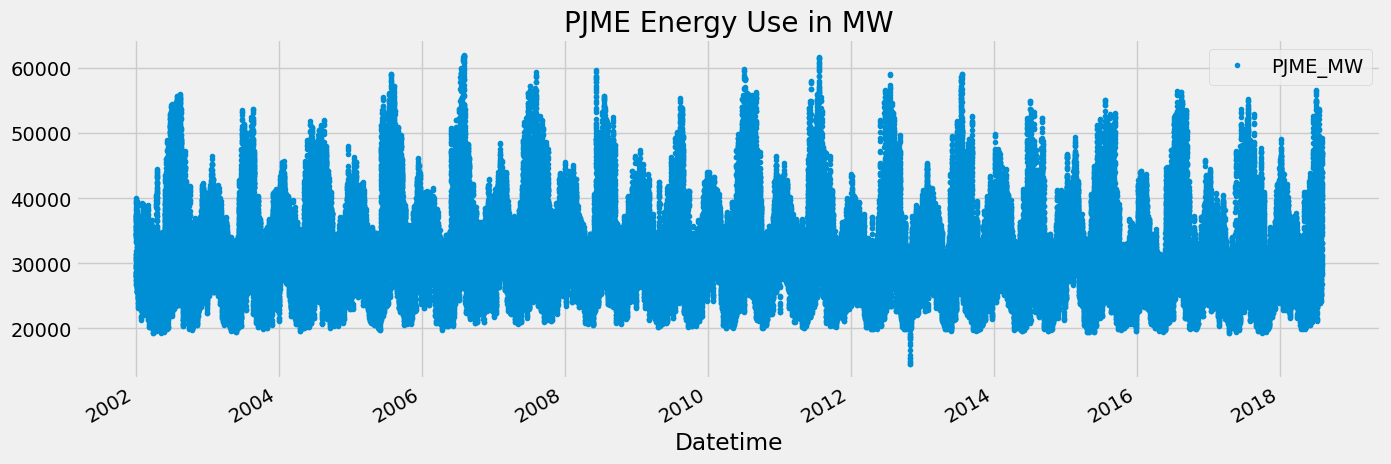

In [49]:
df.plot(style='.',
        figsize=(15,5),
        color=color_pal[0],
        title= 'PJME Energy Use in MW')
plt.plot

### 1. Outlier Analysis and Removal

<Axes: ylabel='Frequency'>

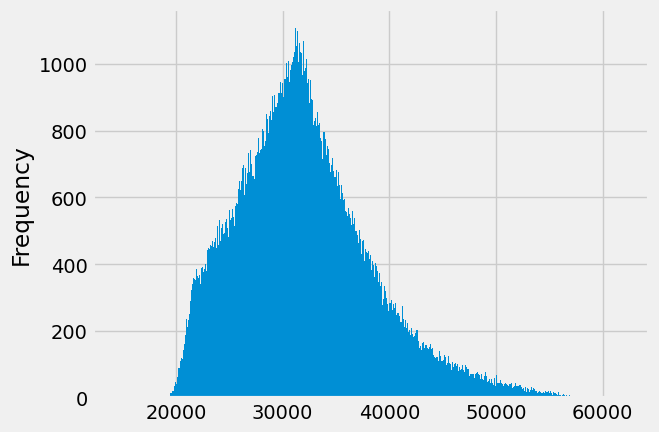

In [50]:
df['PJME_MW'].plot(kind='hist', bins = 500)

<Axes: title={'center': 'Outliers'}, xlabel='Datetime'>

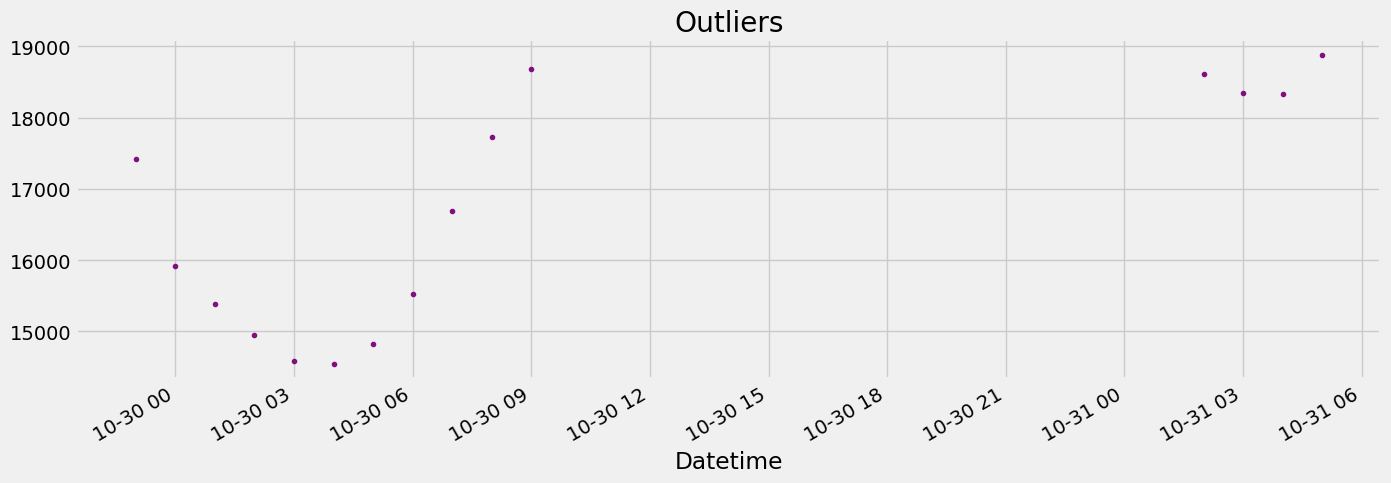

In [51]:
df.query('PJME_MW < 19000')['PJME_MW'] \
    .plot(style='.',
        figsize=(15,5),
        color=color_pal[5],
        title= 'Outliers')
        

In [52]:
df = df.query('PJME_MW > 19000').copy()

### Simple train/test split

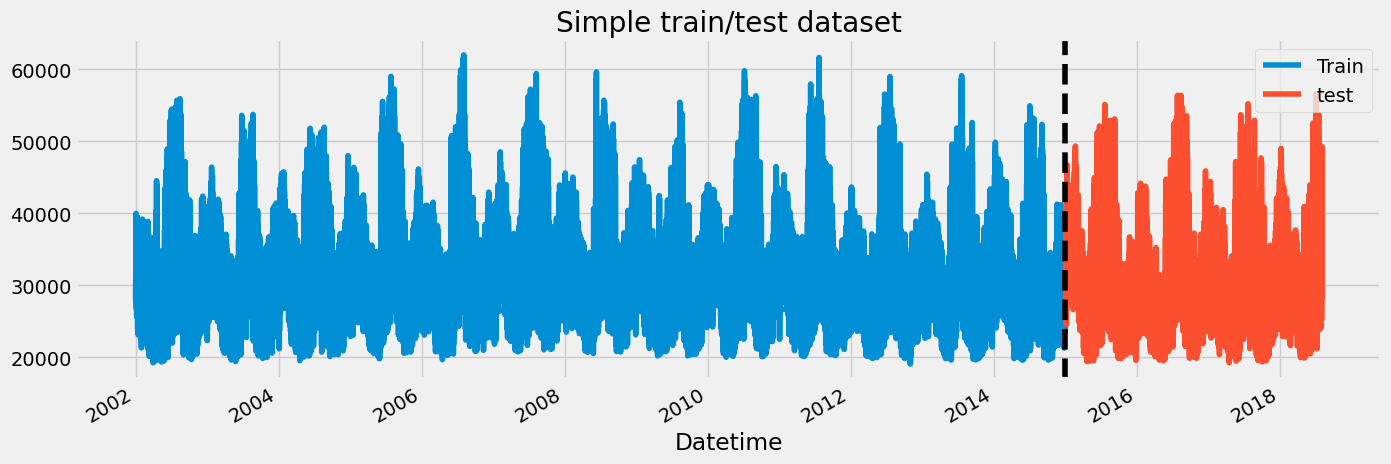

In [53]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax, label='Training Set', title="Simple train/test dataset")
test.plot(ax=ax, label='Testing Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Train', 'test'])

plt.show()


In [54]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()



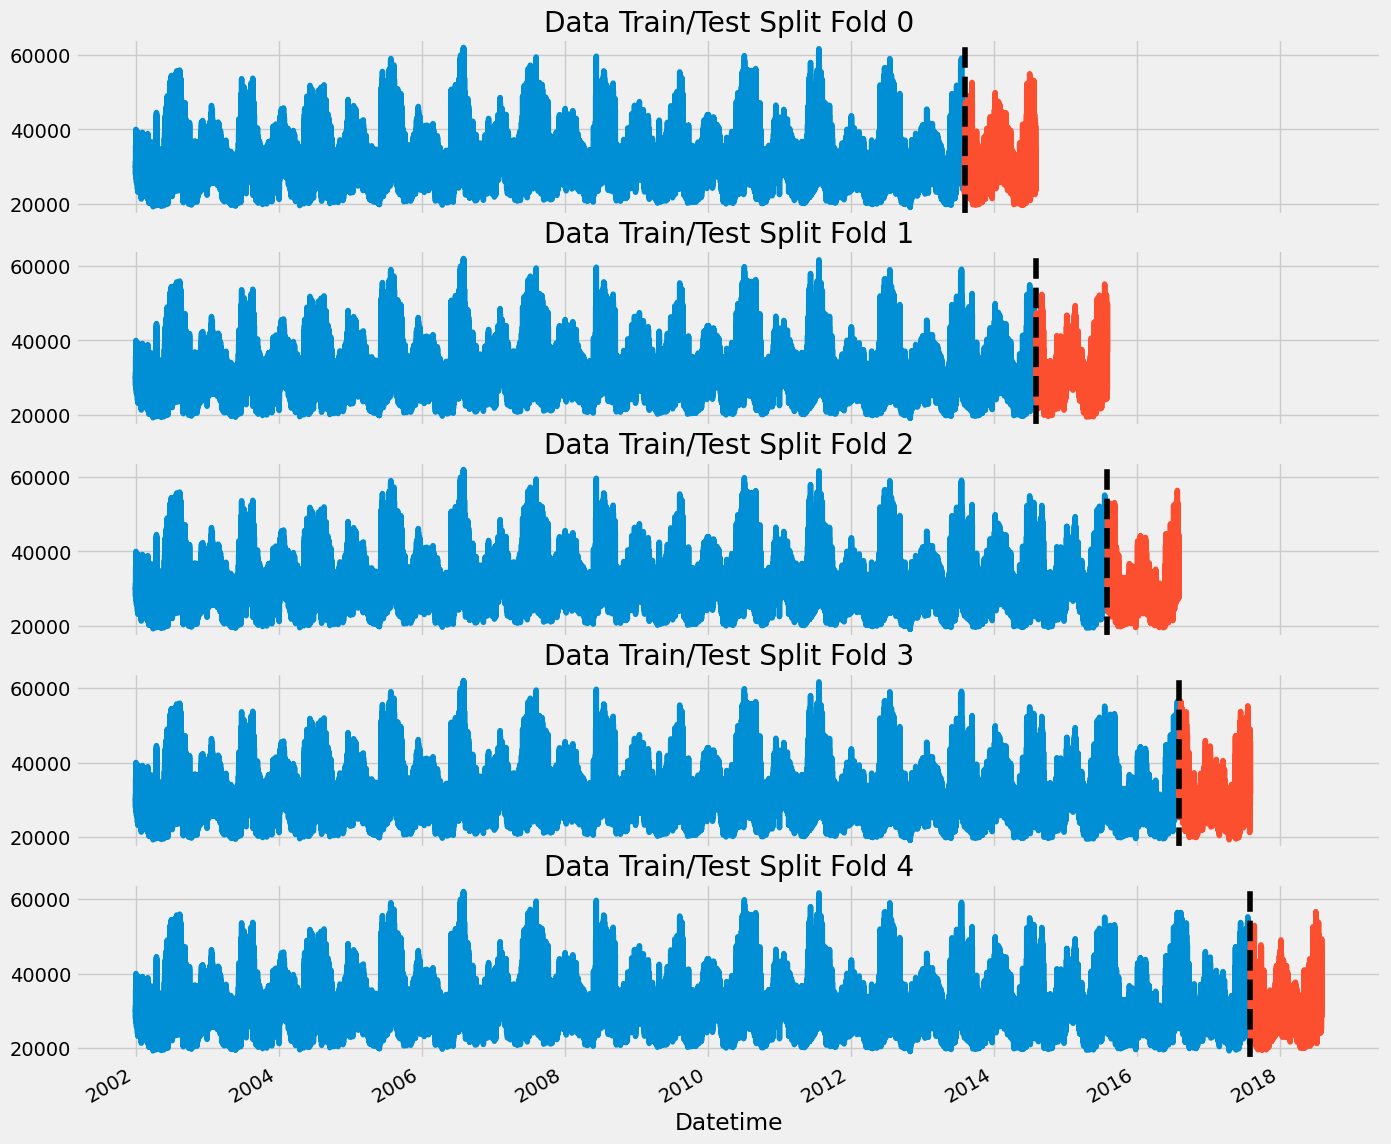

In [55]:
fig, axs = plt.subplots(5, 1, figsize = (15, 15), sharex=True)

fold = 0
for train_indices, test_indices in tss.split(df):
    train = df.iloc[train_indices]
    test = df.iloc[test_indices]
    # print("first indices:")
    # print(test_indices[0])
    # print(train_indices[0])
    train['PJME_MW'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['PJME_MW'].plot(ax=axs[fold],
                         label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.show()

In [56]:
import holidays

us_holidays = holidays.US()

def create_features(df):
    df = df.copy()
    # df['hour'] = df.index.hour
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['julianday'] = df.index.dayofyear
    df['weekofyear'] = df.index.isocalendar().week
    df['isholiday'] = [1 if d in us_holidays else 0 for d in df.index.date]

    return df

df = create_features(df)


In [57]:
df.iloc[100]

PJME_MW        26822.0
hour_sin      0.965926
hour_cos      0.258819
dayofweek          5.0
month              1.0
year            2002.0
julianday          5.0
weekofyear         1.0
isholiday          0.0
Name: 2002-01-05 05:00:00, dtype: Float64

In [58]:
def add_lags(df):
    target_map = df['PJME_MW'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('364 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('728 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('1092 days')).map(target_map)
    return df

df = add_lags(df)

In [59]:
df.columns

Index(['PJME_MW', 'hour_sin', 'hour_cos', 'dayofweek', 'month', 'year',
       'julianday', 'weekofyear', 'isholiday', 'lag1', 'lag2', 'lag3'],
      dtype='object')

In [60]:
fold = 0
preds = []
scores = []
for train_idx, val_idx in tss.split(df):
    print(f'--------------- fold: {fold} -------------')
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    # train = create_features(train)
    # test = create_features(test)

    FEATURES = ['hour_sin', 'hour_cos', 'dayofweek', 'month', 'year',
       'julianday', 'weekofyear', 'isholiday', 'lag1', 'lag2', 'lag3']
    TARGET = 'PJME_MW'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:squarederror',
                           max_depth=3,
                           learning_rate=0.01)
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)
    fold += 1

--------------- fold: 0 -------------
[0]	validation_0-rmse:32732.64189	validation_1-rmse:31956.84085
[100]	validation_0-rmse:12553.46393	validation_1-rmse:11934.91172
[200]	validation_0-rmse:5781.57545	validation_1-rmse:5393.57090
[300]	validation_0-rmse:3888.97186	validation_1-rmse:3903.75198
[400]	validation_0-rmse:3462.31548	validation_1-rmse:3761.15855
[459]	validation_0-rmse:3378.77389	validation_1-rmse:3762.49108
--------------- fold: 1 -------------
[0]	validation_0-rmse:32672.30157	validation_1-rmse:32139.24536
[100]	validation_0-rmse:12530.75691	validation_1-rmse:12252.96466
[200]	validation_0-rmse:5787.40648	validation_1-rmse:5690.48976
[300]	validation_0-rmse:3922.79581	validation_1-rmse:3924.26368
[400]	validation_0-rmse:3500.31533	validation_1-rmse:3594.34567
[500]	validation_0-rmse:3371.52509	validation_1-rmse:3486.00648
[600]	validation_0-rmse:3305.86173	validation_1-rmse:3431.87096
[700]	validation_0-rmse:3262.17061	validation_1-rmse:3404.49838
[800]	validation_0-rmse:

In [61]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 3727.5576
Fold scores:[np.float64(3758.848590474023), np.float64(3363.8107871944), np.float64(3471.493362752243), np.float64(4054.581678725985), np.float64(3989.053581622312)]


### Predictioning with all data

In [62]:
# df.tail()

FEATURES = ['hour_sin', 'hour_cos', 'dayofweek', 'month', 'year',
    'julianday', 'weekofyear', 'isholiday', 'lag1', 'lag2', 'lag3']
TARGET = 'PJME_MW'

X_all= train[FEATURES]
y_all = train[TARGET]

full_reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                            n_estimators=500,
                            objective='reg:squarederror',
                            max_depth=3,
                            learning_rate=0.01) \
                                .fit(X_all, y_all,
                                eval_set=[(X_all, y_all)],
                                verbose=500)



[0]	validation_0-rmse:32462.17074
[499]	validation_0-rmse:3443.60216


In [63]:
df.index.max()

Timestamp('2018-08-03 00:00:00')

In [64]:
future = pd.date_range('2018-08-03', '2019-08-01', freq='1h')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)



In [65]:
future_w_features = df_and_future.query('isFuture').copy()

In [66]:
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])

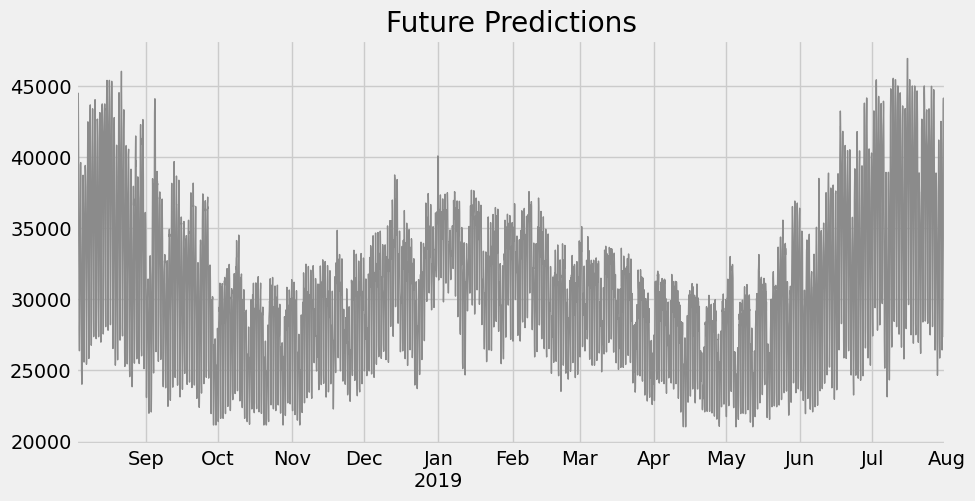

In [67]:
future_w_features['pred'].plot(figsize=(10, 5),
                               color=color_pal[4],
                               ms=1,
                               lw=1,
                               title='Future Predictions')
plt.show()

## Linear Regression

In [68]:


fold = 0
lin_preds = []
lin_scores = []
for train_idx, val_idx in tss.split(df):
   #  print(f'--------------- fold: {fold} -------------')
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    # train = create_features(train)
    # test = create_features(test)

    FEATURES = ['hour_sin', 'hour_cos', 'dayofweek', 'month', 'year',
       'julianday', 'weekofyear', 'isholiday']
    TARGET = 'PJME_MW'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)

    y_pred = lin_reg.predict(X_test)
    lin_preds.append(y_pred)
    lin_score = np.sqrt(mean_squared_error(y_test, y_pred))
    lin_scores.append(lin_score)
    fold += 1

print(lin_preds)
print(np.mean(lin_scores))

[array([29912.47140393, 28031.67594414, 26953.4927012 , ...,
       30622.44257054, 29289.91655071, 31884.08057421], shape=(8760,)), array([30605.17978861, 29777.12137586, 29245.98177407, ...,
       34212.85369098, 32893.21661812, 31015.26421779], shape=(8760,)), array([29799.59067754, 28975.15500878, 28445.38585963, ...,
       33361.08399004, 32049.82470861, 30186.11284128], shape=(8760,)), array([28772.72678684, 27949.17675152, 27418.74820114, ...,
       32293.03941721, 30986.54504068, 29129.91910331], shape=(8760,)), array([27975.16314789, 27151.86989445, 26619.91188499, ...,
       31476.62656933, 30175.16996164, 28334.08674579], shape=(8760,))]
5342.168834201302


# 24h Lag XGBoost Model

In [69]:
# 1. Setup the Exact Features the Model Expects
FEATURES = ['hour_sin', 'hour_cos', 'dayofweek', 'month', 'year',
            'julianday', 'weekofyear', 'isholiday', 
            'lag_24h', 'lag_7d', 'lag1', 'lag2', 'lag3']
TARGET = 'PJME_MW'

# 2. Load the trained model from the joblibs folder
daily_xgb_model = joblib.load('joblibs/PJME_hourly_model.joblib')
print("Model loaded successfully!")


Model loaded successfully!


In [ ]:

def run_recursive_forecast(model, history_df, horizon_hours, target_col, features_list):
    forecast_df = history_df.copy()
    future_predictions = []
    
    us_holidays = holidays.US()

    for _ in range(horizon_hours):

        next_time = forecast_df.index[-1] + pd.Timedelta(hours=1)
        
        next_row = pd.DataFrame(index=[next_time])
        
        next_row['hour_sin'] = np.sin(2 * np.pi * next_time.hour / 24)
        next_row['hour_cos'] = np.cos(2 * np.pi * next_time.hour / 24)
        next_row['dayofweek'] = next_time.dayofweek
        next_row['month'] = next_time.month
        next_row['year'] = next_time.year
        next_row['julianday'] = next_time.dayofyear
        next_row['weekofyear'] = next_time.isocalendar().week
        
        next_row['lag_24h'] = forecast_df.iloc[-24][target_col]
        next_row['lag_7d']  = forecast_df.iloc[-168][target_col]
        next_row['lag1']    = forecast_df.iloc[-8736][target_col]
        next_row['lag2']    = forecast_df.iloc[-17472][target_col]
        next_row['lag3']    = forecast_df.iloc[-26208][target_col]
        
        next_row['isholiday'] = 1 if next_time.date() in us_holidays else 0 

        X_input = next_row[features_list]
        prediction = model.predict(X_input)[0]
        
        next_row[target_col] = prediction
        forecast_df = pd.concat([forecast_df, next_row])
        
        future_predictions.append({
            'Datetime': next_time,
            'Prediction': prediction
        })

    return pd.DataFrame(future_predictions).set_index('Datetime')


In [ ]:

final_forecast = run_recursive_forecast(
    model=daily_xgb_model,
    history_df=df,
    horizon_hours=48, 
    target_col=TARGET, 
    features_list=FEATURES
)

final_forecast.head(10)


,Prediction
Datetime,
2018-08-03 01:00:00,32866.792969
2018-08-03 02:00:00,30839.277344
2018-08-03 03:00:00,29735.970703
2018-08-03 04:00:00,28863.375000
2018-08-03 05:00:00,29051.949219
2018-08-03 06:00:00,30189.255859
2018-08-03 07:00:00,31810.812500
2018-08-03 08:00:00,34842.804688
2018-08-03 09:00:00,36642.199219


## Plot 48 Hour Forecast

 This is a recursive forecast. I realize that it can create exponiential errors, but I was more interested in the methods and how it worked. 

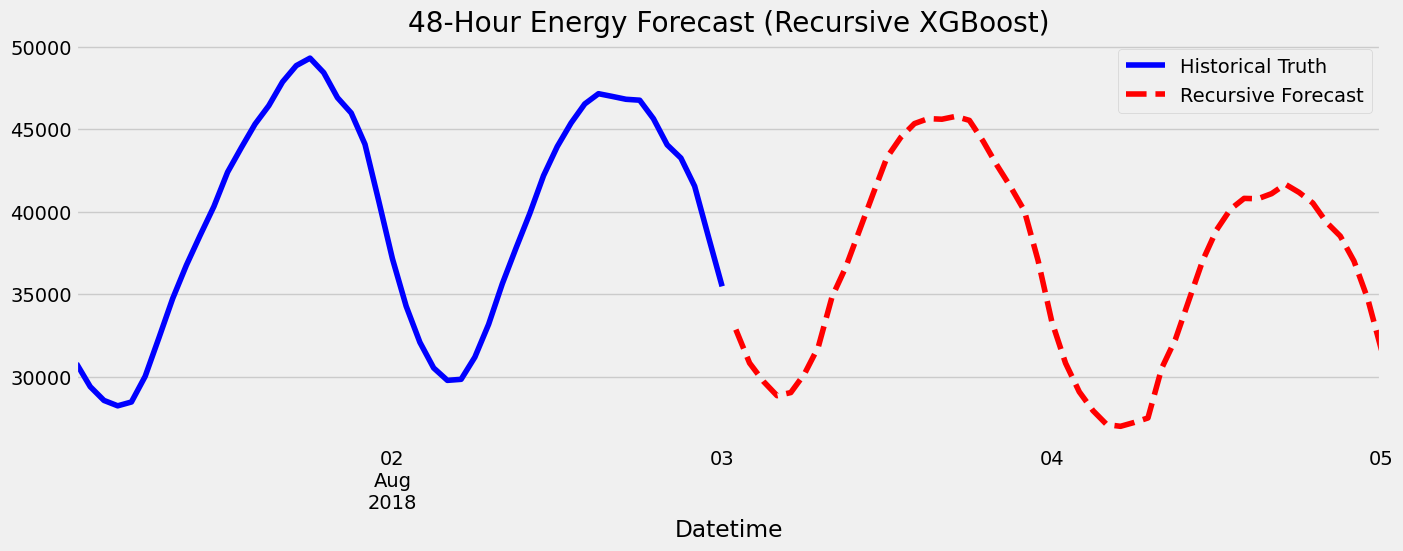

In [ ]:

fig, ax = plt.subplots(figsize=(15, 5))

df[TARGET].iloc[-48:].plot(ax=ax, label='Historical Truth', color='blue')

final_forecast['Prediction'].plot(ax=ax, label='Recursive Forecast', color='red', linestyle='--')

ax.set_title("48-Hour Energy Forecast (Recursive XGBoost)")
ax.legend()
plt.show()
